# Timestep constraints

In [1]:
from lucifex.fdm import AB, CN, AM
from lucifex.sim import run, xdmf_to_npz
from lucifex.viz import plot_line, save_figure, get_ipynb_file_name
from crocodil.dns.system_a import dns_system_a, SYSTEM_A_REFERENCE
from lucifex.solver import OptionsPETSc

STORE = 1
WRITE = None
DIR_BASE = f'./{get_ipynb_file_name()}'
DIR_PARAMS = ('Ra', 'Da', 'epsilon', 'sr', 'cr', 'Nx', 'Ny')

COURANT_ADV = 0.5
COURANT_DIFF = 0.75
COURANT_REAC = 0.1

simulation = dns_system_a(
    store_delta=STORE, 
    write_delta=WRITE, 
    dir_base=DIR_BASE, 
    dir_params=DIR_PARAMS,
)(
    Nx=60,
    Ny=60,
    scaling='advective',
    **SYSTEM_A_REFERENCE,
    D_adv=AB(1)@CN, 
    D_diff=AB(1)@CN,
    D_reac=AB(1)@AM(1),
    D_src=AB(1),
    D_evol=AM(1)@AB(1),
    dt_max=0.1,
    courant_adv=COURANT_ADV,
    courant_diff=COURANT_DIFF,
    courant_reac=COURANT_REAC,
    flow_petsc=(OptionsPETSc('cg', 'hypre'), None),
    diagnostic=True,
)

t_stop = 20.0
n_stop = 600
dt_init = 1e-6
n_init = 10
run(simulation, t_stop=t_stop, n_stop=n_stop, dt_init=dt_init, n_init=n_init)
if WRITE:
    xdmf_to_npz(simulation, delete_xdmf=False)

s, c, u, psi = simulation['s', 'c', 'u', 'psi']

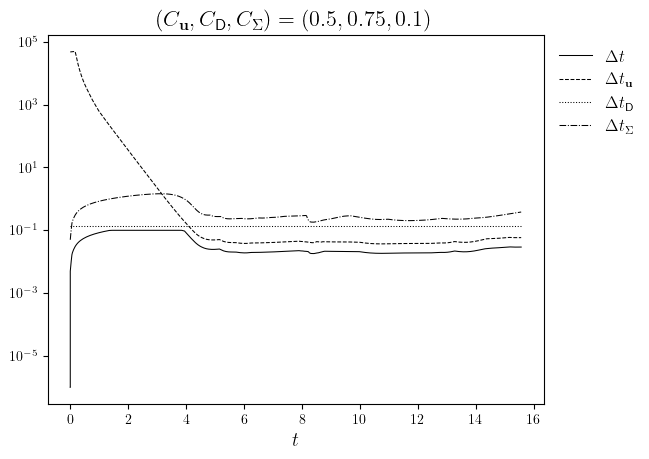

In [2]:
dt, dtU, dtD, dtSigma = simulation['dt', 'dtU', 'dtD', 'dtSigma']

title = f'$(C_{{\mathbf{{u}}}}, C_{{\mathsf{{D}}}}, C_\Sigma)=({COURANT_ADV}, {COURANT_DIFF}, {COURANT_REAC})$'
fig, ax = plot_line(
    [
        (dt.time_series, dt.value_series), 
        (dtU.time_series, dtU.value_series), 
        (dtD.time_series, dtD.value_series), 
        (dtSigma.time_series, dtSigma.value_series),
    ],
    x_label='$t$',
    title=title,
    legend_labels=['$\Delta t$', '$\Delta t_{\mathbf{u}}$', '$\Delta t_{\mathsf{D}}$', '$\Delta t_{\Sigma}$'],
)
ax.set_yscale('log')
save_figure('dt(t)', simulation.dir_path, prefix_ipynb=False)(fig)